In [208]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import joblib

In [209]:
import os
ml_output_path = r"D:\datascience\Analytix_Internship_data_analyst\blinkit\pipeline and batch\ML_Output"
os.makedirs(ml_output_path, exist_ok=True)
print("ML Output Folder:", ml_output_path)

ML Output Folder: D:\datascience\Analytix_Internship_data_analyst\blinkit\pipeline and batch\ML_Output


In [210]:
#reading csv file
path="D:/datascience/Analytix_Internship_data_analyst/blinkit/streamlit/"
orders=pd.read_csv(path+'unclean_data/blinkit_orders.csv')
#delivery=pd.read_csv(path+'unclean_data/blinkit_delivery_performance.csv')
order_items=pd.read_csv(path+'unclean_data/blinkit_order_items.csv')
customers = pd.read_csv(path+"unclean_data/blinkit_customers.csv")


In [211]:
#checking the shapes
print("Orders Shape:", orders.shape)
print("Order_items Shape:", order_items.shape)
print("customers Shape:", customers.shape)
print("Orders Columns:")
print(orders.columns)
print("customers Columns:")
print(customers.columns)
print("order_itemsColumns:")
print(order_items.columns)

Orders Shape: (5000, 10)
Order_items Shape: (5000, 4)
customers Shape: (2500, 11)
Orders Columns:
Index(['order_id', 'customer_id', 'order_date', 'promised_delivery_time',
       'actual_delivery_time', 'delivery_status', 'order_total',
       'payment_method', 'delivery_partner_id', 'store_id'],
      dtype='object')
customers Columns:
Index(['customer_id', 'customer_name', 'email', 'phone', 'address', 'area',
       'pincode', 'registration_date', 'customer_segment', 'total_orders',
       'avg_order_value'],
      dtype='object')
order_itemsColumns:
Index(['order_id', 'product_id', 'quantity', 'unit_price'], dtype='object')


In [212]:
#null values checking
print(orders.isna().sum())
print(customers.isna().sum())
print(order_items.isna().sum())

order_id                  0
customer_id               0
order_date                0
promised_delivery_time    0
actual_delivery_time      0
delivery_status           0
order_total               0
payment_method            0
delivery_partner_id       0
store_id                  0
dtype: int64
customer_id          0
customer_name        0
email                0
phone                0
address              0
area                 0
pincode              0
registration_date    0
customer_segment     0
total_orders         0
avg_order_value      0
dtype: int64
order_id      0
product_id    0
quantity      0
unit_price    0
dtype: int64


In [213]:
#info about orders
orders.groupby("customer_id")["order_id"].count().describe()

count    2172.000000
mean        2.302026
std         1.246990
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         9.000000
Name: order_id, dtype: float64

In [214]:
#info about all the columns
orders.info()
order_items.info()
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                5000 non-null   int64  
 1   customer_id             5000 non-null   int64  
 2   order_date              5000 non-null   object 
 3   promised_delivery_time  5000 non-null   object 
 4   actual_delivery_time    5000 non-null   object 
 5   delivery_status         5000 non-null   object 
 6   order_total             5000 non-null   float64
 7   payment_method          5000 non-null   object 
 8   delivery_partner_id     5000 non-null   int64  
 9   store_id                5000 non-null   int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 390.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   

In [215]:
#creating column
correct_total_orders = (orders.groupby("customer_id")["order_id"].count().reset_index())
correct_total_orders.columns = ["customer_id","correct_total_orders"]
customer_aov = (orders.groupby('customer_id')['order_total'].mean())

In [216]:
#merging table with created dataframe
customers = customers.merge(correct_total_orders,on="customer_id",how="left")


In [217]:
#checking wrong records
wrong_records = customers[customers["total_orders"] != customers["correct_total_orders"]]
print("Wrong Records:", len(wrong_records))


Wrong Records: 2385


In [218]:
#correcting the columns
customers["total_orders"] = customers["correct_total_orders"]
customers.drop(columns=["correct_total_orders"],inplace=True)

In [219]:
#correcting the columns
correct_aov = (orders.groupby("customer_id")["order_total"].mean().reset_index())
correct_aov.columns = ["customer_id","correct_avg_order_value"]
customers = customers.merge(correct_aov,on="customer_id",how="left")
customers["avg_order_value"] = customers["correct_avg_order_value"]
customers.drop(columns=["correct_avg_order_value"],inplace=True)

In [220]:
#rfm
orders["order_date"] = pd.to_datetime(orders["order_date"])
snapshot_date = orders["order_date"].max() + pd.Timedelta(days=1)
rfm = orders.groupby("customer_id").agg({"order_date": lambda x: (snapshot_date - x.max()).days,"order_id": "count","order_total": "sum"})
rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm = rfm.reset_index()
rfm.head()

,customer_id,Recency,Frequency,Monetary
0,31813,26,2,5726.04
1,61020,66,3,7844.90
2,119099,165,4,14768.77
3,188838,260,2,5182.04
4,191616,165,2,4089.96


In [221]:
rfm.describe()

,customer_id,Recency,Frequency,Monetary
count,2.172000e+03,2172.000000,2172.000000,2172.000000
mean,5.011839e+07,207.265193,2.302026,5068.742403
std,2.921306e+07,156.384495,1.246990,3381.984399
min,3.181300e+04,1.000000,1.000000,22.140000
25%,2.412906e+07,74.000000,1.000000,2493.550000
50%,5.060146e+07,171.000000,2.000000,4477.015000
75%,7.620456e+07,316.250000,3.000000,6947.270000
max,9.989390e+07,600.000000,9.000000,21686.800000


In [222]:
# Create scaler object
scaler = StandardScaler()
# Scale Recency, Frequency and Monetary
rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])
# Check shape
print("Scaled Data Shape:", rfm_scaled.shape)

Scaled Data Shape: (2172, 3)


In [223]:
wcss = []
# Try clusters from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    # Train model
    kmeans.fit(rfm_scaled)
    # Store WCSS
    wcss.append(kmeans.inertia_)
wcss

[6516.0,
 3586.977008033933,
 2391.2628944124112,
 1858.9668124697125,
 1560.1167011817192,
 1350.8082258990464,
 1213.903626154532,
 1111.3669732244475,
 1022.1750432731584,
 941.9153576610298]

In [224]:
joblib.dump(kmeans,os.path.join(ml_output_path, "customer_segmentation_model.pkl"))
print("Model Saved")

Model Saved


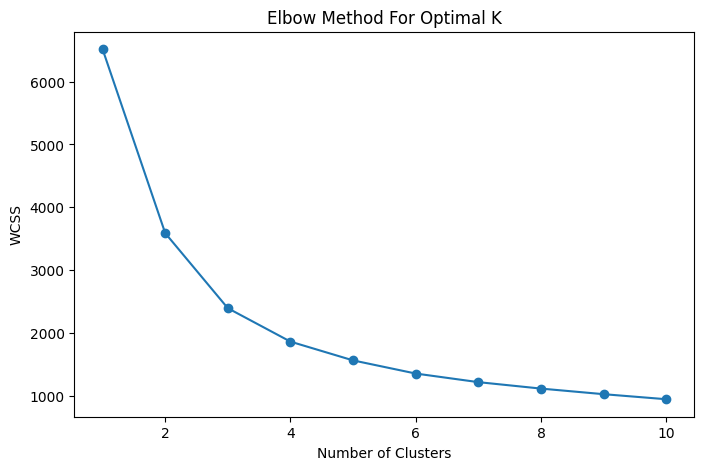

In [225]:
# Create chart
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker="o")
plt.title("Elbow Method For Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.savefig(os.path.join(ml_output_path, "elbow_method.png"),dpi=300,bbox_inches="tight")
plt.show()

In [226]:
# Create final KMeans model
kmeans = KMeans(n_clusters=4,random_state=42,n_init=10)
# Fit model and assign cluster labels
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)
rfm.head()

,customer_id,Recency,Frequency,Monetary,Cluster
0,31813,26,2,5726.04,1
1,61020,66,3,7844.90,0
2,119099,165,4,14768.77,2
3,188838,260,2,5182.04,1
4,191616,165,2,4089.96,1


In [227]:
# Check average RFM values for each cluster
cluster_summary = rfm.groupby("Cluster").agg({"Recency":"mean","Frequency":"mean","Monetary":"mean"})
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,146.395137,3.086626,6959.274468
1,121.515625,1.615057,3005.020881
2,94.596154,4.778846,12049.346298
3,413.004983,1.392027,3003.832508


In [228]:
cluster_summary = rfm.groupby("Cluster").agg({"Recency": "mean","Frequency": "mean","Monetary": "mean"})
cluster_summary.to_csv(os.path.join(ml_output_path, "cluster_summary.csv"))
print("Cluster Summary Saved")

Cluster Summary Saved


In [229]:
# Count customers in each cluster
rfm["Cluster"].value_counts()

Cluster
1    704
0    658
3    602
2    208
Name: count, dtype: int64

In [230]:
# Map cluster names
segment_map = {2: "Premium Customers",0: "Loyal Customers",1: "Regular Customers",3: "At Risk Customers"}
# Create segment column
rfm["Segment"] = rfm["Cluster"].map(segment_map)
rfm.head()

,customer_id,Recency,Frequency,Monetary,Cluster,Segment
0,31813,26,2,5726.04,1,Regular Customers
1,61020,66,3,7844.90,0,Loyal Customers
2,119099,165,4,14768.77,2,Premium Customers
3,188838,260,2,5182.04,1,Regular Customers
4,191616,165,2,4089.96,1,Regular Customers


In [231]:
rfm["Segment"].value_counts()

Segment
Regular Customers    704
Loyal Customers      658
At Risk Customers    602
Premium Customers    208
Name: count, dtype: int64

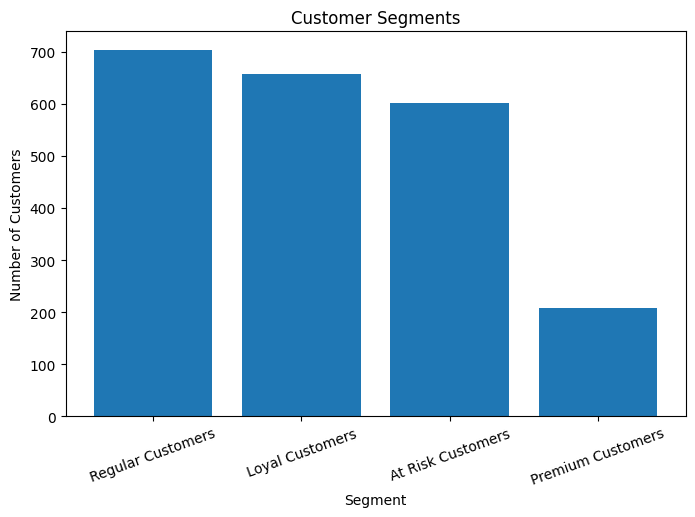

In [232]:
#ploting the chart of segment
segment_counts = rfm["Segment"].value_counts()
plt.figure(figsize=(8,5))
plt.bar(segment_counts.index, segment_counts.values)
plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.savefig(os.path.join(ml_output_path, "cluster_visualization.png"),dpi=300,bbox_inches="tight")
plt.show()

In [233]:
#saving the model
joblib.dump(kmeans, "customer_segmentation_model.pkl")
joblib.dump(scaler, "rfm_scaler.pkl")
print("Model Saved Successfully")

Model Saved Successfully


In [234]:
#saving rfm data
rfm.to_csv("customer_segments.csv", index=False)
print("Dataset Saved")

Dataset Saved


In [235]:
# from sklearn.metrics import silhouette_score
# score = silhouette_score(rfm_scaled,rfm["Cluster"])
# print("Silhouette Score:", score)